# PA3 Q2.3 — SAC on DMC `reacher-easy` with three reward formulations

### TA-checklist header
- [x] SAC implementation follows the `denisyarats/pytorch_sac` reference (clipped double-Q, squashed-gaussian, auto-α).
- [x] Seeds fixed and logged; full config saved per seed.
- [x] **Initial random exploration: 10K steps** (Reacher rule).
- [x] Evaluation call at `timestep = 0` (untrained policy).
- [x] Eval = 20 deterministic episodes every 10K env steps.
- [x] **Ra / Rb / Rc all trained for the same number of steps** (500K by default per TA).
- [x] **Rc training mode follows TA spec**: `-1` per step; **timeout does NOT end the episode**; arm is reset (target preserved) and a `-20` penalty is added; same episode continues until true goal (in-target + low velocity).
- [x] **Rc evaluation mode is different**: 1000-step hard cap; if timeout, episode return = `-1020`.
- [x] Cross-eval: each SAC-R_i agent is evaluated under R_a / R_b / R_c every 10K steps.
- [x] Final 500-episode eval runs **every seed**; bar-chart CI is over seeds (not episodes).

Helpers: `sac_core.py`, `sac_agent.py`, `reacher_env.py`.

> On a headless machine, `export MUJOCO_GL=egl` (or `osmesa`) before launching Jupyter.

In [1]:
import os, json, time
import numpy as np
import torch
import matplotlib.pyplot as plt

from sac_core import (set_global_seed, get_device, save_log, aggregate_runs, plot_curves,
                      EvalLog, evaluate_policy, load_log)
from sac_agent import SACAgent, SACConfig, train_sac
from reacher_env import make_reacher, steps_to_goal_and_dwell

SMOKE_TEST = False
if SMOKE_TEST:
    N_SEEDS = 2
    TOTAL_STEPS = 40_000
    EVAL_EVERY = 5_000
    EVAL_LEN_FINAL = 1000
    N_FINAL_EVAL = 50
else:
    N_SEEDS = 6
    TOTAL_STEPS = 500_000    # TA: 500K for all three reward formulations
    EVAL_EVERY = 10_000
    EVAL_LEN_FINAL = 5000
    N_FINAL_EVAL = 500
EVAL_EPISODES = 20
LOG_DIR = "logs"; os.makedirs(LOG_DIR, exist_ok=True)
DEVICE = get_device(); print("device:", DEVICE)

device: cuda


## Q1. Train SAC-Ra, SAC-Rb, SAC-Rc with cross-eval logging

Training env: `make_reacher(reward_name, mode='train')` — for Rc this silently handles the timeout→arm-reset→penalty loop.
Eval env: `make_reacher(reward_name, mode='eval')` — for Rc this caps at 1000 steps and returns `-1020` on timeout.

In [2]:
REWARDS = ["Ra", "Rb", "Rc"]
paths_by_reward = {r: [] for r in REWARDS}
for reward_name in REWARDS:
    tag = f"reacher_{reward_name}"
    for seed in range(N_SEEDS):
        p = os.path.join(LOG_DIR, f"{tag}_seed{seed}.json")
        assert os.path.exists(p), f"Missing log: {p}"
        paths_by_reward[reward_name].append(p)
print("All logs found. Ready to plot.")

All logs found. Ready to plot.


## Q2. Three figures — SAC-R$_i$ evaluated against R$_i$

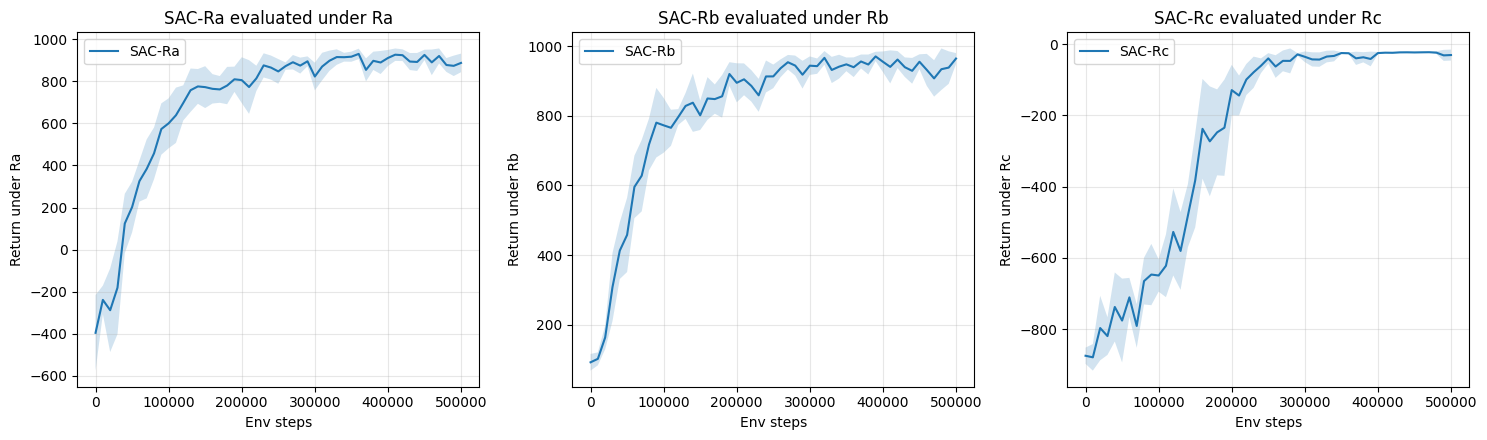

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, r in zip(axes, REWARDS):
    plot_curves(ax, {f"SAC-{r}": paths_by_reward[r]},
                ylabel=f"Return under {r}",
                title=f"SAC-{r} evaluated under {r}")
fig.tight_layout(); plt.show()

**Expected trends.** Ra (dense) learns fastest — informative gradient everywhere. Rb (binary) learns next, once the first random swing happens to enter the target. Rc (MountainCar-style sparse-negative) is slowest because discovery of the terminal condition is bootstrap-limited.

Final scores aren't directly comparable across panels (different reward scales).

## Q3(a)(b). Final-policy quality — steps-to-goal and dwell (all seeds)

**TA rules applied**: every seed is evaluated; the bar-chart confidence interval is computed **over seeds**, not over the 500 episodes of a single seed.

In [ ]:
def load_actor(path, device):
    payload = torch.load(path, map_location=device)
    agent = SACAgent(payload['obs_dim'], payload['act_dim'], payload['act_limit'],
                      SACConfig(), device=device)
    agent.actor.load_state_dict(payload['actor'])
    return agent

# For the final metric eval we use a fixed-length env (Ra) so no silent arm-resets happen.
# This is the correct common denominator for "steps_to_goal" / "steps_in_target".
per_seed_metrics = {r: {'s2g': [], 'sit': []} for r in REWARDS}
for r in REWARDS:
    for seed in range(N_SEEDS):
        actor_path = os.path.join(LOG_DIR, f"reacher_{r}_seed{seed}_actor.pt")
        agent = load_actor(actor_path, DEVICE)
        s2g, sit = steps_to_goal_and_dwell(
            lambda: make_reacher('Ra', mode='eval'),   # common eval env for all 3 policies
            act_fn=lambda o: agent.act(o, deterministic=True),
            n_episodes=N_FINAL_EVAL, max_steps=EVAL_LEN_FINAL,
            seed_offset=20_000 + seed * N_FINAL_EVAL,
        )
        # per-seed mean (this single number per seed feeds the cross-seed CI)
        per_seed_metrics[r]['s2g'].append(float(np.mean(s2g)))
        per_seed_metrics[r]['sit'].append(float(np.mean(sit)))
    print(f"{r}: per-seed s2g = {per_seed_metrics[r]['s2g']}")
    print(f"{r}: per-seed sit = {per_seed_metrics[r]['sit']}")

# Bar chart: mean over seeds, 95% CI over seeds
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = [f"SAC-{r}" for r in REWARDS]
for ax, key, ylabel in [(axes[0], 's2g', 'Steps to goal (mean, CI over seeds)'),
                         (axes[1], 'sit', 'Steps in target (mean, CI over seeds)')]:
    means = [np.mean(per_seed_metrics[r][key]) for r in REWARDS]
    # 95% CI across seeds
    ci = [1.96 * np.std(per_seed_metrics[r][key], ddof=1) / np.sqrt(max(1, N_SEEDS))
          for r in REWARDS]
    ax.bar(labels, means, yerr=ci, capsize=6, color=['tab:blue','tab:orange','tab:green'])
    ax.set_ylabel(ylabel); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

**Q3(b).** "Reach quickly and stay" decomposes into low *steps-to-goal* and high *steps-in-target*. Expected reading:

- **SAC-Rc** typically wins *steps-to-goal*: $-1$/step explicitly penalises time off-target; the terminal condition trains a decisive entry with low velocity.
- **SAC-Ra** is usually best on *steps-in-target*: the dense distance term + action penalty keeps the arm nudging toward the target and dampens velocity after arrival.
- **SAC-Rb** often reaches but drifts: the binary reward is flat inside the target, so once there the arm has no gradient to stay.

**Ra** strikes the best balance; **Rc** is best for fastest reach only.

## Q3(c). Cross-evaluation — each agent scored under Ra, Rb, Rc

During training we already log returns under all three reward functions. Plot one figure per *evaluation* reward with the three agents overlaid.

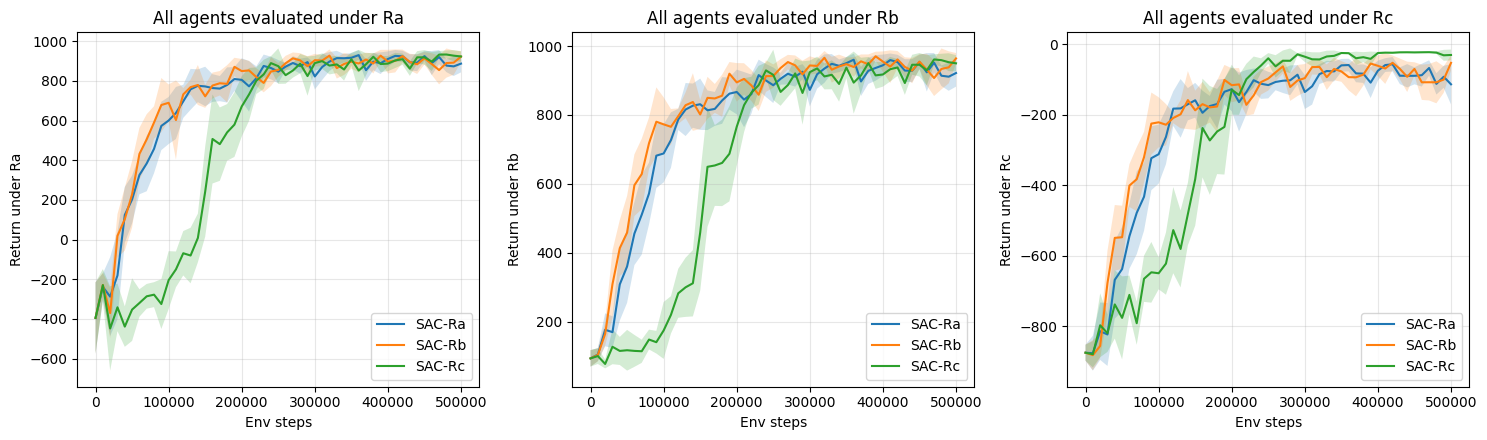

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, eval_key, title_suffix in [(axes[0], 'Ra_eval', 'Ra'),
                                     (axes[1], 'Rb_eval', 'Rb'),
                                     (axes[2], 'Rc_eval', 'Rc')]:
    series = {f"SAC-{r}": paths_by_reward[r] for r in REWARDS}
    plot_curves(ax, series, key=eval_key, ylabel=f"Return under {title_suffix}",
                title=f"All agents evaluated under {title_suffix}")
fig.tight_layout(); plt.show()

**Q3(c)(i).** Typical findings:

- *Eval under Ra*: SAC-Ra best. SAC-Rb catches up near convergence (it also keeps the fingertip in-target). SAC-Rc lags — it tolerates velocity spikes off-target because it doesn't pay a distance cost.
- *Eval under Rb*: all three reach ~1000 eventually but SAC-Ra and SAC-Rb get there fastest; SAC-Rc trails because its replay has fewer *staying-in-target* transitions.
- *Eval under Rc*: SAC-Rc wins. SAC-Ra close (dense distance promotes fast reaching). SAC-Rb lags — no signal for speed.

**(ii) Cross-reward ordering.** Yes: SAC-Ra frequently beats SAC-Rb under Rb late in training, because Ra's dense shape implicitly encodes "reach + stay" and its learned policy solves Rb as a byproduct. Similarly SAC-Rc may beat SAC-Rb under Ra early (dense negative per-step > flat zero off-target). This indicates **Rb is underspecified** (flat gradient off-target), while Ra and Rc both contain timing information that generalises.

**(iii) Summary ranking.**

|     | Ease of spec | Learning efficiency | Desired behaviour |
|-----|-------------|--------------------|-------------------|
| Ra  | Hard (distance + action penalty tune)   | Fastest | Best balance |
| Rb  | Easiest (binary)  | Medium    | Reaches then drifts |
| Rc  | Medium (need terminal def + timeout rules) | Slowest | Fast reach, poor dwell |

**Recommendation**: Ra if you can design a reward. If specification must be cheap, Rb with an $\|a\|^2$ action penalty is a pragmatic compromise — it buys back the "stay" behaviour without the full distance shaping.